## Amplitude predictor

Prediction of the behavour of a transient process. The process is described with synthetic data.
The output of the process is the final amplitude of a damped oscillation. The oscillation has a fixed frequency, a given time and a given damping. In the beginning of the script a dataset with a final amplitude depending on oscillation time and damping is calculated.

From this data a model with PolynomialFeatures is trained with LinearRegression.

The predictive capability of the model over all test data is tested with r2_score. Finally the predicted test data are compared with the true test data.

R² score of the model: 0.9958


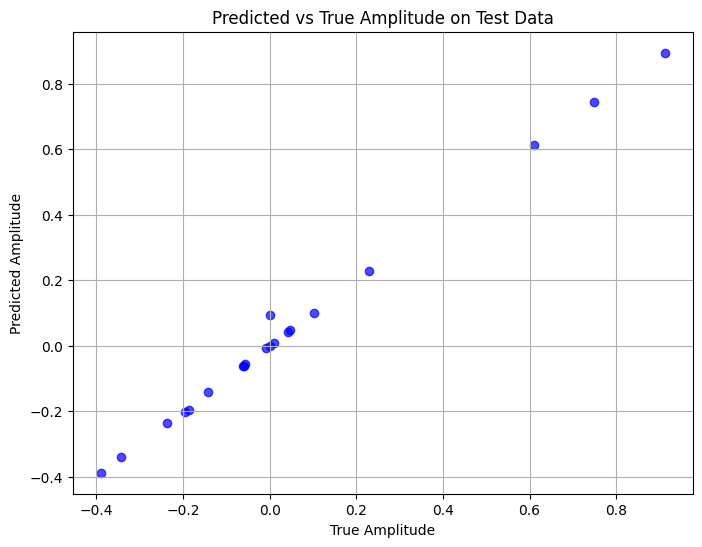

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate synthetic data
t = np.random.uniform(0, 10, 100)       # Time values
tau = np.random.uniform(0, 10, 100)     # Damping parameter

# Amplitude with damping: A(t) = exp(-t/tau) * cos(omega * t), omega = 1
omega = 1
amplitude = np.exp(-t / tau) * np.cos(omega * t)

# Create DataFrame
data = pd.DataFrame({
    't': t,
    'tau': tau,
    'amplitude': amplitude
})

# Features and label
X = data[['t', 'tau']]
y = data['amplitude']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Polynomial features
poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predict and evaluate
y_pred = model.predict(X_test_poly)
r2 = r2_score(y_test, y_pred)

# Print R² score
print(f"R² score of the model: {r2:.4f}")

# Plot predicted vs true amplitude using matplotlib
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.xlabel('True Amplitude')
plt.ylabel('Predicted Amplitude')
plt.title('Predicted vs True Amplitude on Test Data')
plt.grid(True)
plt.savefig("predicted_vs_true_amplitude_matplotlib.png")
plt.show()

In [2]:
dat = pd.DataFrame([t,
                     tau,
                     amplitude])
dat

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,3.745401,9.507143,7.319939,5.986585,1.560186,1.559945,0.580836,8.661761,6.011150,7.080726,...,1.195942,7.132448,7.607850,5.612772,7.709672,4.937956,5.227328,4.275410,0.254191,1.078914
1,0.314292,6.364104,3.143560,5.085707,9.075665,2.492922,4.103829,7.555511,2.287982,0.769799,...,0.931028,8.972158,9.004181,6.331015,3.390298,3.492096,7.259557,8.971103,8.870864,7.798755
2,-0.000005,-0.223741,0.049597,0.294703,0.008934,0.005804,0.725672,-0.229672,0.069618,0.000071,...,0.101338,0.298300,0.104671,0.322887,0.014797,0.054385,0.239702,-0.262770,0.940527,0.411266
